In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import sys


In [2]:
# metrics_dict = {'SUBJECT': 'Subject'
#                 ,'LABEL': 'Label'
#                 ,'ADJRIND':
#                 ,'AUC':
#                 ,'AVGDIST':
#                 ,'DICE':
#                 ,'FN':
#                 ,'FP':
#                 ,'HDRFDST':
#                 ,'JACRD':
#                 ,'MUTINF':
#                 ,'PRCISON':
#                 ,'RNDIND':
#                 ,'SNSVTY':
#                 ,'SPCFTY':
#                 ,'TN':
#                 ,'TP':
#                 ,'VOLSMTY'}

In [3]:
# # File path to your CSV
file_path_small = "../../MIALAB Workspace/Numerical results/results_small_labels_2024-12-02-18-51-13.csv"  # Update this to the actual path of your file

# Load and preprocess the data
data_small = pd.read_csv(file_path_small, delimiter = ';')

# File path to your CSV
file_path_large = "../../MIALAB Workspace/Numerical results/results_large_labels_2024-12-02-20-49-57.csv"  # Update this to the actual path of your file

# Load and preprocess the data
data_large = pd.read_csv(file_path_large, delimiter = ';')

# File path to your CSV
file_path_all = "../../MIALAB Workspace/Numerical results/results_all_labels_2024-12-02-19-31-23.csv"  # Update this to the actual path of your file

# Load and preprocess the data
data_all = pd.read_csv(file_path_all, delimiter = ';')
# data.describe()
# data.head(10)


In [4]:
data_small.head()

,SUBJECT,LABEL,ADJRIND,AUC,AVGDIST,DICE,FN,FP,HDRFDST,JACRD,MUTINF,PRCISON,RNDIND,SNSVTY,SPCFTY,TN,TP,VOLSMTY
0,117122,Amygdala,0.384353,0.932201,1.937343,0.385054,405.0,7906.0,34.336569,0.238431,0.002767,0.247621,0.998086,0.865314,0.999088,8664376.0,2602.0,0.444987
1,117122,Hippocampus,0.397685,0.992297,1.890966,0.399832,108.0,25608.0,33.896903,0.249869,0.007986,0.250658,0.994089,0.987549,0.997045,8641007.0,8566.0,0.404873
2,117122,Thalamus,0.610455,0.991709,0.929659,0.613033,243.0,21147.0,50.000000,0.441995,0.015828,0.444815,0.995081,0.985861,0.997558,8636956.0,16943.0,0.621825
3,117122-PP,Amygdala,0.392540,0.932218,1.671423,0.393230,405.0,7625.0,16.401219,0.244733,0.002781,0.254425,0.998150,0.865314,0.999121,8664657.0,2602.0,0.454436
4,117122-PP,Hippocampus,0.411407,0.992379,1.547215,0.413497,108.0,24192.0,19.209373,0.260634,0.008055,0.261493,0.994414,0.987549,0.997209,8642423.0,8566.0,0.418710


In [5]:
# Combine small and large datasets
combined_data = pd.concat([data_small, data_large])
combined_data.head(10)

,SUBJECT,LABEL,ADJRIND,AUC,AVGDIST,DICE,FN,FP,HDRFDST,JACRD,MUTINF,PRCISON,RNDIND,SNSVTY,SPCFTY,TN,TP,VOLSMTY
0,117122,Amygdala,0.384353,0.932201,1.937343,0.385054,405.0,7906.0,34.336569,0.238431,0.002767,0.247621,0.998086,0.865314,0.999088,8664376.0,2602.0,0.444987
1,117122,Hippocampus,0.397685,0.992297,1.890966,0.399832,108.0,25608.0,33.896903,0.249869,0.007986,0.250658,0.994089,0.987549,0.997045,8641007.0,8566.0,0.404873
2,117122,Thalamus,0.610455,0.991709,0.929659,0.613033,243.0,21147.0,50.000000,0.441995,0.015828,0.444815,0.995081,0.985861,0.997558,8636956.0,16943.0,0.621825
3,117122-PP,Amygdala,0.392540,0.932218,1.671423,0.393230,405.0,7625.0,16.401219,0.244733,0.002781,0.254425,0.998150,0.865314,0.999121,8664657.0,2602.0,0.454436
4,117122-PP,Hippocampus,0.411407,0.992379,1.547215,0.413497,108.0,24192.0,19.209373,0.260634,0.008055,0.261493,0.994414,0.987549,0.997209,8642423.0,8566.0,0.418710
5,117122-PP,Thalamus,0.612526,0.991691,0.918202,0.615089,244.0,20960.0,50.000000,0.444136,0.015845,0.446995,0.995124,0.985802,0.997579,8637143.0,16942.0,0.623947
6,118528,Amygdala,0.369868,0.923716,2.128513,0.370608,474.0,8537.0,31.384710,0.227452,0.002771,0.237087,0.997925,0.848417,0.999016,8663625.0,2653.0,0.436823
7,118528,Hippocampus,0.386278,0.995026,1.934645,0.388773,63.0,30620.0,29.983329,0.241290,0.008864,0.241666,0.992951,0.993585,0.996466,8634848.0,9758.0,0.391283
8,118528,Thalamus,0.590387,0.996094,0.954672,0.593282,90.0,24636.0,34.292856,0.421749,0.016590,0.422639,0.994316,0.995034,0.997154,8632529.0,18034.0,0.596243
9,118528-PP,Amygdala,0.380406,0.923260,1.840203,0.381130,477.0,8129.0,17.349352,0.235430,0.002786,0.245848,0.998018,0.847458,0.999063,8664033.0,2650.0,0.449734


In [6]:

# Analyze the differences for the subjects normal and post-processing for the metrics of each label
labels = combined_data['LABEL'].unique()
metrics = combined_data.columns[2:]  # Exclude 'SUBJECT' and 'LABEL' columns
metrics = ['DICE']
for label in labels:
    normal_subjects_combined = combined_data[(combined_data['LABEL'] == label) & (~combined_data['SUBJECT'].str.contains('-PP'))]
    post_processing_subjects_combined = combined_data[(combined_data['LABEL'] == label) & (combined_data['SUBJECT'].str.contains('-PP'))]
    
    normal_subjects_all = data_all[(data_all['LABEL'] == label) & (~data_all['SUBJECT'].str.contains('-PP'))]
    post_processing_subjects_all = data_all[(data_all['LABEL'] == label) & (data_all['SUBJECT'].str.contains('-PP'))]
    
    print(f"Label: {label}")
    for metric in metrics:
        normal_mean_combined = normal_subjects_combined[metric].mean()
        post_processing_mean_combined = post_processing_subjects_combined[metric].mean()
        difference_combined = post_processing_mean_combined - normal_mean_combined
        
        normal_mean_all = normal_subjects_all[metric].mean()
        post_processing_mean_all = post_processing_subjects_all[metric].mean()
        difference_all = post_processing_mean_all - normal_mean_all
        
        print(f"  Metric: {metric}")
        print(f"    Combined Data - Normal Mean: {normal_mean_combined:.4f}, Post-Processing Mean: {post_processing_mean_combined:.4f}, Mean Difference: {difference_combined:.4f}")
        print(f"    All Data - Normal Mean: {normal_mean_all:.4f}, Post-Processing Mean: {post_processing_mean_all:.4f}, Mean Difference: {difference_all:.4f}")
        print(f"    All Data - Optimised regions model Mean Difference (PP): {post_processing_mean_combined - post_processing_mean_all:.4f}, Percentage of original performance: {(1 + (post_processing_mean_combined - post_processing_mean_all)/post_processing_mean_all)*100:.4f}%")
        
    print("\n")

Label: Amygdala
  Metric: DICE
    Combined Data - Normal Mean: 0.4317, Post-Processing Mean: 0.4424, Mean Difference: 0.0107
    All Data - Normal Mean: 0.5160, Post-Processing Mean: 0.5290, Mean Difference: 0.0130
    All Data - Optimised regions model Mean Difference (PP): -0.0866, Percentage of original performance: 83.6233%


Label: Hippocampus
  Metric: DICE
    Combined Data - Normal Mean: 0.3713, Post-Processing Mean: 0.3841, Mean Difference: 0.0128
    All Data - Normal Mean: 0.4991, Post-Processing Mean: 0.5204, Mean Difference: 0.0213
    All Data - Optimised regions model Mean Difference (PP): -0.1363, Percentage of original performance: 73.8034%


Label: Thalamus
  Metric: DICE
    Combined Data - Normal Mean: 0.6066, Post-Processing Mean: 0.6091, Mean Difference: 0.0025
    All Data - Normal Mean: 0.7444, Post-Processing Mean: 0.7590, Mean Difference: 0.0146
    All Data - Optimised regions model Mean Difference (PP): -0.1499, Percentage of original performance: 80.2507%


In [7]:
data_small.groupby('LABEL').describe()
data_small.groupby('LABEL').apply(lambda x: x.describe())

ADJRIND        AUC    AVGDIST       DICE          FN  \
LABEL                                                                       
Amygdala    count  20.000000  20.000000  20.000000  20.000000   20.000000   
            mean    0.436292   0.960457   1.605455   0.437018  260.050000   
            std     0.040138   0.028450   0.306411   0.040134  194.883899   
            min     0.369868   0.915866   1.020196   0.370608   61.000000   
            25%     0.412778   0.932213   1.385553   0.413532   82.000000   
            50%     0.432706   0.967227   1.666724   0.433478  210.500000   
            75%     0.463477   0.988488   1.845363   0.464166  405.000000   
            max     0.509495   0.990269   2.128513   0.510186  629.000000   
Hippocampus count  20.000000  20.000000  20.000000  20.000000   20.000000   
            mean    0.375418   0.987639   1.841014   0.377708  192.750000   
            std     0.016528   0.008980   0.167865   0.016517  174.267452   
            min     0.345024   0.963967   1.547215   0.347358   63.000000   
            25%     0.365579   0.983327   1.718563   0.367928  104.000000   
            50%     0.371857   0.991652   1.877894   0.374207  119.000000   
            75%     0.385865   0.992479   1.937980   0.388270  235.250000   
            max     0.411407   0.995106   2.173391   0.413497  669.000000   
Thalamus    count  20.000000  20.000000  20.000000  20.000000   20.000000   
            mean    0.605166   0.993873   0.922624   0.607875  171.750000   
            std     0.024958   0.002253   0.102787   0.024827   81.962042   
            min     0.573101   0.989728   0.722945   0.576058   82.000000   
            25%     0.587274   0.991704   0.844196   0.589883   97.000000   
            50%     0.601650   0.994421   0.933665   0.604377  152.000000   
            75%     0.622291   0.996023   1.023348   0.625033  243.250000   
            max     0.658147   0.996185   1.053103   0.660483  314.000000   

                             FP    HDRFDST      JACRD     MUTINF    PRCISON  \
LABEL                                                                         
Amygdala    count     20.000000  20.000000  20.000000  20.000000  20.000000   
            mean    7649.300000  27.366433   0.280410   0.003362   0.286878   
            std      546.065554   9.252501   0.033031   0.000412   0.030938   
            min     6606.000000  12.369317   0.227452   0.002767   0.237087   
            25%     7281.500000  16.424062   0.260663   0.003217   0.264387   
            50%     7694.000000  32.108810   0.276729   0.003295   0.286830   
            75%     8065.250000  34.387385   0.302233   0.003606   0.308652   
            max     8537.000000  36.837481   0.342450   0.004066   0.345098   
Hippocampus count     20.000000  20.000000  20.000000  20.000000  20.000000   
            mean   28610.050000  27.318238   0.232945   0.007950   0.234145   
            std     2014.153929   5.983651   0.012593   0.000487   0.012553   
            min    24192.000000  18.788294   0.210183   0.006891   0.211589   
            25%    27370.250000  21.217609   0.225439   0.007873   0.226100   
            50%    28981.000000  29.899716   0.230170   0.008020   0.232420   
            75%    30081.750000  32.634338   0.240902   0.008113   0.242530   
            max    31555.000000  35.566838   0.260634   0.008929   0.261493   
Thalamus    count     20.000000  20.000000  20.000000  20.000000  20.000000   
            mean   22543.450000  26.454792   0.437092   0.016321   0.438977   
            std     2005.537636  13.736006   0.025919   0.000734   0.026206   
            min    18082.000000  11.000000   0.404552   0.015039   0.407506   
            25%    21761.750000  12.597580   0.418323   0.015841   0.419648   
            50%    22309.500000  24.807551   0.433107   0.016351   0.434967   
            75%    24060.000000  38.283261   0.454580   0.016917   0.456375   
            max    25482.000000  50.000000 

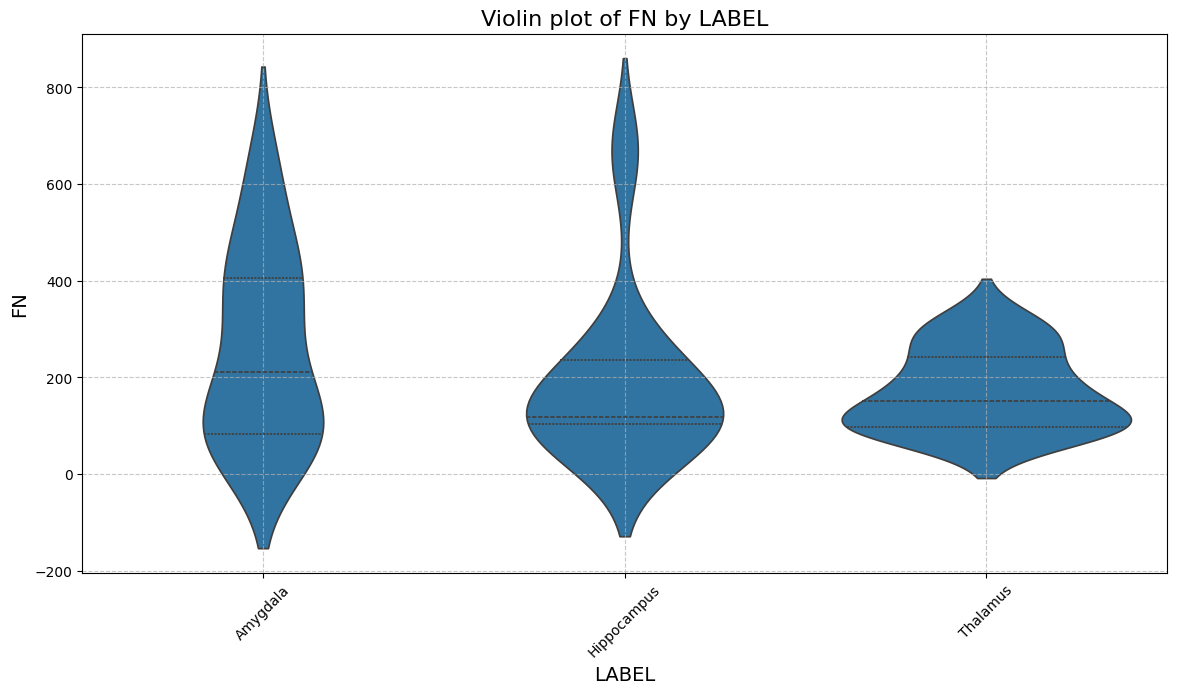

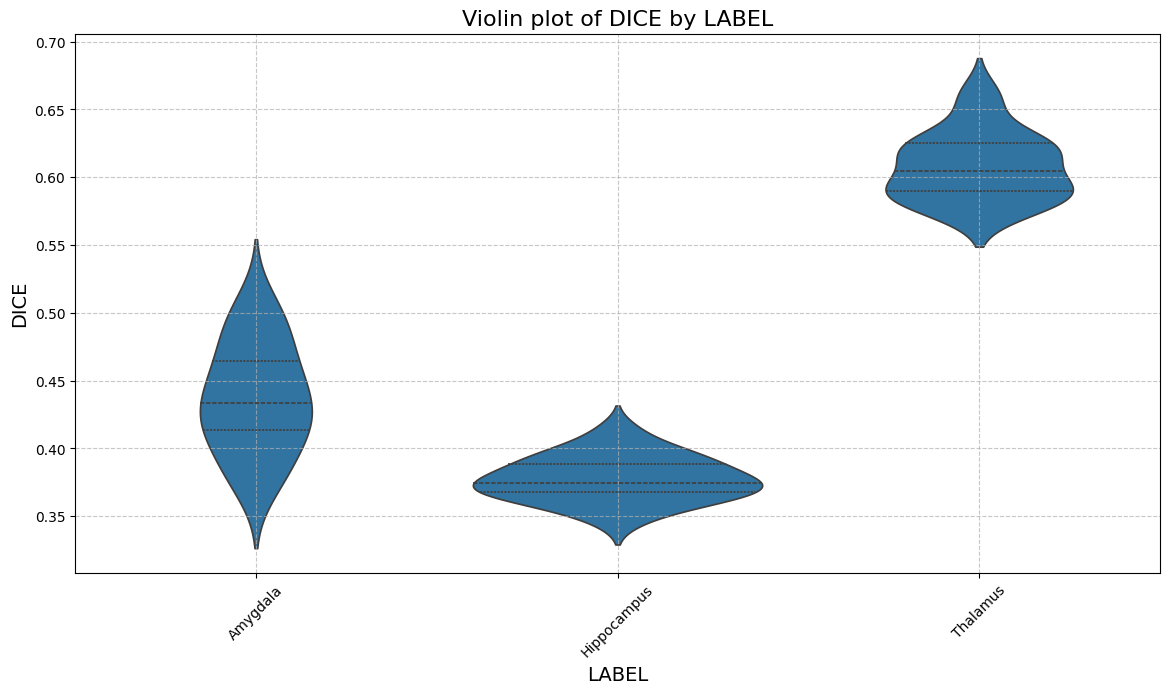

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_metric_distributions(data, metrics):
    for metric in metrics:
        plt.figure(figsize=(14, 7))
        ax = data.boxplot(column=metric, by='LABEL', grid=False, patch_artist=True)
        plt.title(f'Distribution of {metric} by LABEL', fontsize=16)
        plt.suptitle('')  # Suppress the default title to avoid overlap
        plt.xlabel('LABEL', fontsize=14)
        plt.ylabel(metric, fontsize=14)
        plt.xticks(rotation=45)
        plt.grid(True, linestyle='--', alpha=0.7)

def plot_violin_plots(data, metrics):
    for metric in metrics:
        plt.figure(figsize=(14, 7))
        sns.violinplot(x='LABEL', y=metric, data=data, inner='quartile')
        plt.title(f'Violin plot of {metric} by LABEL', fontsize=16)
        plt.xlabel('LABEL', fontsize=14)
        plt.ylabel(metric, fontsize=14)
        plt.xticks(rotation=45)
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.show()

plot_violin_plots(data_small, metrics=['FN', 'DICE'])

In [ ]:
#todo create plotting for the non optimised models
# create plotting for the small and large structure models
# IDEA: maybe something with red and white? plot also confidence intervals? also